In [59]:
import pandas as pd

df = pd.read_csv('../../files/results/data.csv').drop(columns=['Unnamed: 0', 'ano_primeiro_registro', 'ano_ingresso_final',
       'periodo_primeiro', 'periodo_ingresso_final', 'percentil_media',
       'reprovado', 'is_trancado', 'target_percntil_media', 'target_reprov',
       'target_trancamento', 'risco', 'target_risco'])

In [60]:
df.columns

Index(['id_discente', 'ano', 'periodo', 'id_disciplina', 'situacao', 'sexo',
       'estado_civil', 'raca_declarada', 'discente_nivel', 'id_curso',
       'id_curriculo', 'id_estrutura_curricular', 'ano_ingresso',
       'periodo_ingresso', 'status_discente', 'forma_ingresso',
       'quantidade_membros_familia', 'ch_integralizada', 'ch_pendente',
       'media_geral', 'ano_nascimento', 'faixa_renda_familiar',
       'uf_titulo_eleitor_pb', 'uf_naturalidade_pb', 'pais_origem_br',
       'id_detalhe', 'nome', 'ch_aula', 'ch_laboratorio', 'ch_total',
       'cr_aula', 'cr_laboratorio', 'cr_estagio', 'ch_ead',
       'sigla_departamento', 'nivel_componente_curricular', 'sigla_academica',
       'nome_departamento', 'sigla_centro', 'nome_centro',
       'qtd_max_matriculas', 'codigo_componente_curricular',
       'nome_componete_curricular', 'descricao_tipo_componente_curricular',
       'excluir_avaliacao_institucional', 'ativo', 'curso_nome',
       'curso_unidade_nome', 'campus', 'curso

primeira target: média por percentil

In [61]:
# target 1, de maneira simples usaremos a média do aluno, o ruim é que não captura tendência

# analisando por tamanho qual a melhor composição para agregar pela média
print(df.groupby(['curso_nome']).size().describe())
print(df.groupby(['curso_nome', 'periodo']).size().describe())
print(df.groupby(['curso_nome', 'ano', 'periodo']).size().describe())

count      21.000000
mean      825.809524
std       763.068190
min        14.000000
25%       234.000000
50%       585.000000
75%      1449.000000
max      2583.000000
dtype: float64
count      39.000000
mean      444.666667
std       373.445715
min        14.000000
25%       128.000000
50%       300.000000
75%       739.500000
max      1292.000000
dtype: float64
count    281.000000
mean      61.715302
std       40.410007
min        1.000000
25%       29.000000
50%       57.000000
75%       88.000000
max      202.000000
dtype: float64


Justificativa:

A escolha do nível de agregação da variável target foi baseada no trade-off entre viés e variância.

O agrupamento por curso apresenta baixa variância da média devido ao alto número de observações por grupo (média ≈ 826), porém introduz alto viés ao ignorar variações temporais relevantes para o desempenho discente.

O agrupamento por curso + ano + período, apesar de capturar dinâmicas temporais importantes, apresenta alta variância (média ≈ 62 observações por grupo, com casos mínimos de 1), tornando as estimativas instáveis e suscetíveis a ruído.

O agrupamento por curso + período representa um compromisso adequado, mantendo tamanho amostral suficiente (média ≈ 445) para garantir estabilidade estatística, enquanto incorpora parcialmente a progressão acadêmica, relevante para o problema de predição de risco acadêmico.

Dessa forma, essa agregação minimiza o erro total ao equilibrar viés e variância.

In [62]:
# criando variavel do primeiro quartil da média
q1 = df.groupby(['curso_nome', 'periodo'])['media_geral'].transform(lambda x: x.quantile(0.25))

# criando target
df['target_media_percentil'] = (df['media_geral'] <= q1).astype(int)
df['target_media_percentil'].value_counts()

target_media_percentil
0    44211
1     4236
Name: count, dtype: int64

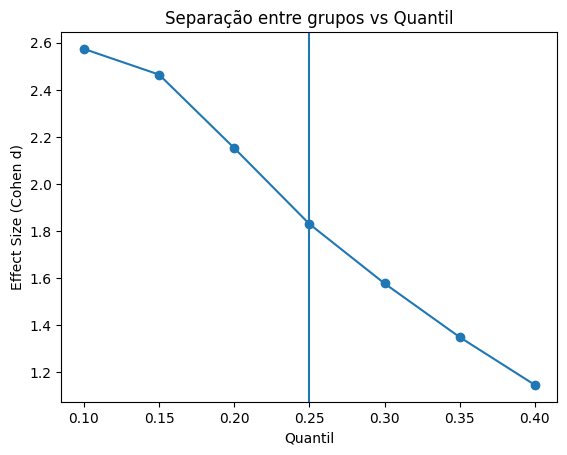

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

quantis = np.arange(0.1, 0.41, 0.05)

effect_sizes = []
proporcoes = []

for q in quantis:
    threshold = df.groupby(['curso_nome', 'periodo'])['media_geral'] \
                  .transform(lambda x: x.quantile(q))
    
    target = (df['media_geral'] <= threshold)
    
    grupo_risco = df[target]['ch_pendente'].dropna()
    grupo_nao = df[~target]['ch_pendente'].dropna()
    
    # médias
    m1, m2 = grupo_risco.mean(), grupo_nao.mean()
    
    # desvios
    s1, s2 = grupo_risco.std(), grupo_nao.std()
    
    # tamanho
    n1, n2 = len(grupo_risco), len(grupo_nao)
    
    # pooled std
    s_pooled = np.sqrt(((n1-1)*s1**2 + (n2-1)*s2**2) / (n1+n2-2))
    
    # effect size
    d = (m1 - m2) / s_pooled if s_pooled != 0 else 0
    
    effect_sizes.append(d)
    proporcoes.append(target.mean())

resultado = pd.DataFrame({
    'quantil': quantis,
    'effect_size': effect_sizes,
    'proporcao': proporcoes
})

# gráfico principal
plt.figure()
plt.plot(resultado['quantil'], resultado['effect_size'], marker='o')
plt.axvline(x=0.25)
plt.xlabel('Quantil')
plt.ylabel('Effect Size (Cohen d)')
plt.title('Separação entre grupos vs Quantil')
plt.show()

In [64]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score

quantis = np.arange(0.1, 0.41, 0.05)

variaveis = [
    'ch_pendente',
    'ch_integralizada',
    'periodo_curso',
    'faixa_renda_familiar'  # pode causar erro
]

# filtrar apenas numéricas
variaveis_numericas = [
    var for var in variaveis
    if pd.api.types.is_numeric_dtype(df[var])
]

resultados = []

for q in quantis:
    
    threshold = df.groupby(['curso_nome', 'periodo'])['media_geral'] \
                  .transform(lambda x: x.quantile(q))
    
    target = (df['media_geral'] <= threshold)
    
    aucs = []
    
    for var in variaveis_numericas:
        df_aux = df[[var]].copy()
        df_aux['target'] = target
        
        df_aux = df_aux.dropna()
        
        if df_aux[var].nunique() > 1:
            auc = roc_auc_score(df_aux['target'], df_aux[var])
            auc = max(auc, 1 - auc)
            aucs.append(auc)
    
    if len(aucs) > 0:
        resultados.append({
            'quantil': q,
            'auc_media': np.mean(aucs),
            'auc_std': np.std(aucs)
        })

resultado_df = pd.DataFrame(resultados).sort_values('auc_media', ascending=False)

print(resultado_df)

   quantil  auc_media   auc_std
0     0.10   0.934389  0.013076
1     0.15   0.905916  0.033676
2     0.20   0.866426  0.048978
3     0.25   0.829507  0.055755
4     0.30   0.795660  0.059069
5     0.35   0.756711  0.059998
6     0.40   0.721463  0.061127


## Definição da variável target

O objetivo deste trabalho é identificar discentes com desempenho acadêmico relativamente baixo dentro de seu contexto específico. Para isso, a variável target foi definida com base na posição do aluno na distribuição de médias de seu grupo, considerando a agregação por curso e período.

Formalmente, seja \( \mu_i \) a média geral do discente \( i \), pertencente ao grupo \( (c, p) \), onde \( c \) representa o curso e \( p \) o período. Define-se o primeiro quartil da distribuição como:

\[
Q1_{c,p} = \text{percentil 25} \left( \{ \mu_j \mid j \in (c,p) \} \right)
\]

A variável target \( y_i \) é definida como:

\[
y_i =
\begin{cases}
1, & \text{se } \mu_i \leq Q1_{c,p} \\
0, & \text{caso contrário}
\end{cases}
\]

---

## Justificativa da abordagem

A utilização de quartis permite avaliar o desempenho de forma relativa ao contexto acadêmico do discente, evitando comparações diretas entre cursos com distribuições de notas distintas.

### Limitações de abordagens alternativas

A adoção de limiares absolutos ou normalizações globais apresenta limitações importantes:

- **Threshold fixo (ex: média < 5)**  
  - ignora a heterogeneidade entre cursos  
  - pode introduzir viés contra cursos mais exigentes  

- **Z-score global**  
  - mistura distribuições com características distintas  
  - assume homogeneidade que não é observada nos dados  

Dessa forma, essas abordagens podem gerar classificações inconsistentes e pouco interpretáveis.

---

## Vantagens do uso de quartis

A definição da variável target com base no primeiro quartil apresenta as seguintes vantagens:

- **Normalização por contexto:** compara o discente apenas com seus pares diretos (mesmo curso e período)  
- **Robustez a outliers:** baseada em ordenação, menos sensível a valores extremos  
- **Balanceamento natural:** aproximadamente 25% dos casos são classificados como positivos  
- **Sensibilidade estrutural:** captura diferenças entre cursos e estágios da formação  
- **Adaptabilidade temporal:** ajusta-se dinamicamente a mudanças na distribuição de desempenho  

---

## Justificativa da escolha do percentil 25

Embora o uso de quartis seja uma prática estatística consolidada, a escolha do ponto de corte foi também validada empiricamente por meio de uma análise de sensibilidade.

Foram avaliados diferentes quantis da distribuição (10%, 15%, 20%, 25%, 30% e 40%), medindo-se a capacidade discriminativa da variável target em relação a variáveis explicativas, utilizando a métrica AUC (Area Under the ROC Curve).

Observou-se que:

- Quantis mais baixos (ex: 10%) apresentam maior AUC, pois capturam casos mais extremos e facilmente separáveis
- Entretanto, esses quantis resultam em tamanhos amostrais reduzidos, comprometendo a estabilidade estatística e a generalização
- À medida que o quantil aumenta, há redução gradual da capacidade discriminativa, devido à inclusão de casos menos extremos

O percentil 25 apresentou um **equilíbrio adequado entre separabilidade e robustez**, mantendo elevado poder discriminativo (AUC ≈ 0.83) e tamanho amostral suficiente para análises estáveis.

---

### Interpretação da métrica AUC

A capacidade discriminativa da variável target foi avaliada utilizando a métrica AUC (*Area Under the ROC Curve*).

De forma intuitiva, a AUC mede o quão bem uma variável consegue **diferenciar dois grupos** — neste caso, discentes de baixo desempenho (Q1) e os demais.

Uma interpretação simples é:

> A AUC representa a probabilidade de que um discente do grupo de risco tenha um valor mais “indicativo de risco” do que um discente fora desse grupo.

Os valores da AUC variam entre 0 e 1:

- **0.5** → nenhuma capacidade de separação (equivalente ao acaso)  
- **0.6 – 0.7** → separação fraca  
- **0.7 – 0.8** → boa capacidade discriminativa  
- **0.8 – 0.9** → separação forte  
- **1.0** → separação perfeita  

Dessa forma, valores mais altos de AUC indicam que a variável target está melhor definida, ou seja, é mais facilmente distinguível a partir das características dos discentes.

---

## Conclusão

A definição da variável target baseada no primeiro quartil por grupo (curso, período) não é arbitrária, mas fundamentada em:

- princípios estatísticos (uso de quartis)
- adequação ao problema (identificação de cauda inferior)
- validação empírica (análise de sensibilidade)

Essa abordagem permite identificar discentes em situação de risco acadêmico relativo de forma consistente, interpretável e robusta.

In [65]:
# agora criando modelo para q1 e q4 e comparando

q1 = df.groupby(['curso_nome', 'periodo'])['media_geral'] \
       .transform(lambda x: x.quantile(0.25))

q3 = df.groupby(['curso_nome', 'periodo'])['media_geral'] \
       .transform(lambda x: x.quantile(0.75))

df['grupo'] = np.nan
df.loc[df['media_geral'] <= q1, 'grupo'] = 0  # Q1
df.loc[df['media_geral'] >= q3, 'grupo'] = 1  # Q4

df_extremos = df.dropna(subset=['grupo'])

# usando variveis sem leakage

features = [
    'ch_pendente',
    'ch_integralizada',
    'periodo_curso',
    'cr_aula',
    'cr_laboratorio',
    'quantidade_membros_familia'
]

In [66]:
from sklearn.model_selection import train_test_split

# features
X = df_extremos[features]
y = df_extremos['grupo']

# transformar categóricas
X = pd.get_dummies(X, drop_first=True)

# remover NaN
data = pd.concat([X, y], axis=1).dropna()

X = data.drop(columns=['grupo'])
y = data['grupo']

# split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# scaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [67]:
# regressão logística

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [68]:
coef = pd.DataFrame({
    'variavel': X.columns,
    'coeficiente': model.coef_[0]
})

coef['impacto'] = coef['coeficiente'].apply(
    lambda x: 'Q4 (alto desempenho)' if x > 0 else 'Q1 (baixo desempenho)'
)

coef['magnitude'] = coef['coeficiente'].abs()

coef = coef.sort_values('magnitude', ascending=False)

print(coef.head(15))

                     variavel  coeficiente                impacto  magnitude
0                 ch_pendente    -1.591796  Q1 (baixo desempenho)   1.591796
1            ch_integralizada     0.763941   Q4 (alto desempenho)   0.763941
5             periodo_curso_I    -0.344252  Q1 (baixo desempenho)   0.344252
2                     cr_aula    -0.232753  Q1 (baixo desempenho)   0.232753
3              cr_laboratorio    -0.020430  Q1 (baixo desempenho)   0.020430
4  quantidade_membros_familia     0.009954   Q4 (alto desempenho)   0.009954
6             periodo_curso_N    -0.005822  Q1 (baixo desempenho)   0.005822


In [69]:
df.columns

Index(['id_discente', 'ano', 'periodo', 'id_disciplina', 'situacao', 'sexo',
       'estado_civil', 'raca_declarada', 'discente_nivel', 'id_curso',
       'id_curriculo', 'id_estrutura_curricular', 'ano_ingresso',
       'periodo_ingresso', 'status_discente', 'forma_ingresso',
       'quantidade_membros_familia', 'ch_integralizada', 'ch_pendente',
       'media_geral', 'ano_nascimento', 'faixa_renda_familiar',
       'uf_titulo_eleitor_pb', 'uf_naturalidade_pb', 'pais_origem_br',
       'id_detalhe', 'nome', 'ch_aula', 'ch_laboratorio', 'ch_total',
       'cr_aula', 'cr_laboratorio', 'cr_estagio', 'ch_ead',
       'sigla_departamento', 'nivel_componente_curricular', 'sigla_academica',
       'nome_departamento', 'sigla_centro', 'nome_centro',
       'qtd_max_matriculas', 'codigo_componente_curricular',
       'nome_componete_curricular', 'descricao_tipo_componente_curricular',
       'excluir_avaliacao_institucional', 'ativo', 'curso_nome',
       'curso_unidade_nome', 'campus', 'curso

In [80]:
import numpy as np
import pandas as pd

# =========================
# 1. TARGET (Q1 vs Q4)
# =========================

q1 = df.groupby(['curso_nome', 'periodo'])['media_geral'] \
       .transform(lambda x: x.quantile(0.25))

q3 = df.groupby(['curso_nome', 'periodo'])['media_geral'] \
       .transform(lambda x: x.quantile(0.75))

df['grupo'] = np.nan
df.loc[df['media_geral'] <= q1, 'grupo'] = 0
df.loc[df['media_geral'] >= q3, 'grupo'] = 1

df_extremos = df.dropna(subset=['grupo']).copy()

# =========================
# 2. CAMADAS
# =========================

camada_1_trajetoria = [
    'periodo_curso',
    'ano_ingresso',
    'periodo_ingresso',
    'forma_ingresso'
]

camada_2_performance = [
    'cr_aula',
    'cr_laboratorio',
    'cr_estagio',
    'ch_aula',
    'ch_laboratorio',
    'ch_ead'
]

camada_3_socio = [
    'sexo',
    'estado_civil',
    'raca_declarada',
    'faixa_renda_familiar',
    'quantidade_membros_familia'
]

camada_4_institucional = [
    'campus',
    'turno_estrutura_curricular',
    'sigla_centro',
    'nivel_componente_curricular'
]

# =========================
# 3. FUNÇÃO DE MODELO
# =========================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score


def rodar_modelo(df, features, nome_modelo="modelo"):

    print(f"\n🔎 {nome_modelo}")

    # garantir colunas existentes
    features = [f for f in features if f in df.columns]

    X = df[features].copy()
    y = df['grupo']

    # remover colunas muito vazias
    threshold = 0.7
    cols_validas = X.columns[X.isnull().mean() < threshold]
    X = X[cols_validas]

    # imputação
    for col in X.select_dtypes(include=['number']).columns:
        X[col] = X[col].fillna(X[col].median())

    for col in X.select_dtypes(include=['object']).columns:
        X[col] = X[col].fillna('desconhecido')

    # encoding
    X = pd.get_dummies(X, drop_first=True)

    # split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # scaler
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # modelo
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train_scaled, y_train)

    # avaliação
    y_pred = model.predict_proba(X_test_scaled)[:, 1]
    auc = roc_auc_score(y_test, y_pred)

    print(f"AUC: {auc:.4f}")

    # coeficientes
    coef = pd.DataFrame({
        'variavel': X.columns,
        'coeficiente': model.coef_[0]
    })

    coef['impacto'] = coef['coeficiente'].apply(
        lambda x: 'Q4 (alto desempenho)' if x > 0 else 'Q1 (baixo desempenho)'
    )

    coef['magnitude'] = coef['coeficiente'].abs()

    coef = coef.sort_values('magnitude', ascending=False)

    return coef, auc

In [81]:
# Modelo 1
coef1, auc1 = rodar_modelo(
    df_extremos,
    camada_1_trajetoria,
    "Trajetória"
)

# Modelo 2
coef2, auc2 = rodar_modelo(
    df_extremos,
    camada_1_trajetoria + camada_2_performance,
    "Trajetória + Performance"
)

# Modelo 3
coef3, auc3 = rodar_modelo(
    df_extremos,
    camada_1_trajetoria + camada_2_performance + camada_3_socio,
    " + Socioeconômico"
)

# Modelo 4
coef4, auc4 = rodar_modelo(
    df_extremos,
    camada_1_trajetoria + camada_2_performance + camada_3_socio + camada_4_institucional,
    " + Institucional"
)


🔎 Trajetória
AUC: 0.6262

🔎 Trajetória + Performance
AUC: 0.6561

🔎  + Socioeconômico
AUC: 0.7408

🔎  + Institucional
AUC: 0.7469


C:\Users\Usuario\AppData\Local\Temp\ipykernel_15148\2387718147.py:84: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in X.select_dtypes(include=['object']).columns:
C:\Users\Usuario\AppData\Local\Temp\ipykernel_15148\2387718147.py:84: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user

In [82]:
comparacao = pd.DataFrame({
    'modelo': [
        'Trajetória',
        'Trajetória + Performance',
        '+ Socioeconômico',
        '+ Institucional'
    ],
    'AUC': [auc1, auc2, auc3, auc4]
})

print(comparacao)

                     modelo       AUC
0                Trajetória  0.626233
1  Trajetória + Performance  0.656050
2          + Socioeconômico  0.740804
3           + Institucional  0.746923


Shape final: (3692, 34)
AUC: 0.9319

=== TOP FATORES ===

                    grupo                                          variavel  \
26   Q4 (alto desempenho)                         status_discente_CONCLUÍDO   
1    Q4 (alto desempenho)                                      ano_ingresso   
33  Q1 (baixo desempenho)                                campus_João Pessoa   
4   Q1 (baixo desempenho)                                       ch_pendente   
21   Q4 (alto desempenho)                  forma_ingresso_PROCESSO SELETIVO   
18  Q1 (baixo desempenho)                       faixa_renda_familiar_ate_1k   
28  Q1 (baixo desempenho)  turno_estrutura_curricular_Matutino e Vespertino   
19   Q4 (alto desempenho)                       forma_ingresso_POR CONVÊNIO   
14  Q1 (baixo desempenho)                              raca_declarada_Outra   
10  Q1 (baixo desempenho)                                            sexo_M   
3    Q4 (alto desempenho)                                  ch_integraliza

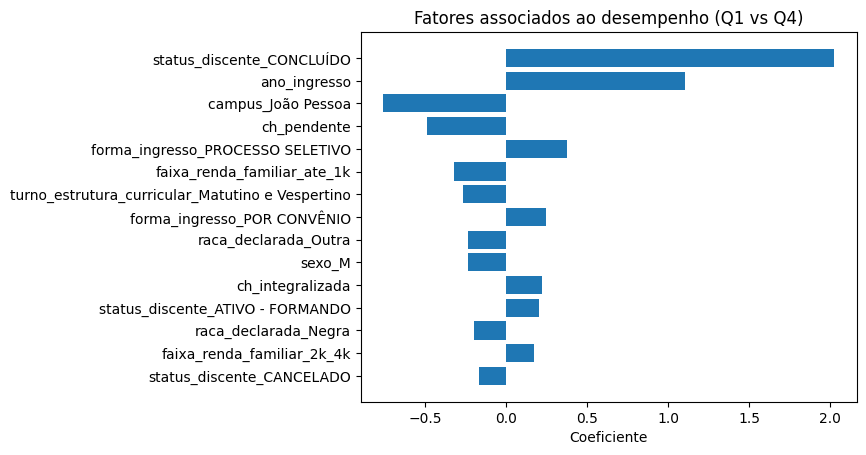


=== INTERPRETAÇÃO ===

status_discente_CONCLUÍDO: associado ao ALTO desempenho (Q4) | OR=7.57
ano_ingresso: associado ao ALTO desempenho (Q4) | OR=3.02
campus_João Pessoa: associado ao BAIXO desempenho (Q1) | OR=0.47
ch_pendente: associado ao BAIXO desempenho (Q1) | OR=0.62
forma_ingresso_PROCESSO SELETIVO: associado ao ALTO desempenho (Q4) | OR=1.45
faixa_renda_familiar_ate_1k: associado ao BAIXO desempenho (Q1) | OR=0.73
turno_estrutura_curricular_Matutino e Vespertino: associado ao BAIXO desempenho (Q1) | OR=0.77
forma_ingresso_POR CONVÊNIO: associado ao ALTO desempenho (Q4) | OR=1.28
raca_declarada_Outra: associado ao BAIXO desempenho (Q1) | OR=0.79
sexo_M: associado ao BAIXO desempenho (Q1) | OR=0.79
ch_integralizada: associado ao ALTO desempenho (Q4) | OR=1.25
status_discente_ATIVO - FORMANDO: associado ao ALTO desempenho (Q4) | OR=1.23
raca_declarada_Negra: associado ao BAIXO desempenho (Q1) | OR=0.82
faixa_renda_familiar_2k_4k: associado ao ALTO desempenho (Q4) | OR=1.19
statu

In [89]:
# =========================
# PIPELINE FINAL - Q1 vs Q4
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1. TARGET (Q1 vs Q4)
# =========================

q1 = df.groupby(['curso_nome', 'periodo'])['media_geral'] \
       .transform(lambda x: x.quantile(0.25))

q3 = df.groupby(['curso_nome', 'periodo'])['media_geral'] \
       .transform(lambda x: x.quantile(0.75))

df['grupo'] = np.nan
df.loc[df['media_geral'] <= q1, 'grupo'] = 0  # Q1
df.loc[df['media_geral'] >= q3, 'grupo'] = 1  # Q4

df_extremos = df.dropna(subset=['grupo']).copy()

# =========================
# 2. FEATURES SELECIONADAS
# =========================

features = [

    # 🟢 Discente (individual)
    'sexo',
    'raca_declarada',
    'faixa_renda_familiar',
    'forma_ingresso',
    'status_discente',
    'quantidade_membros_familia',
    'ano_ingresso',
    'periodo_ingresso',
    'ch_integralizada',
    'ch_pendente',

    # 🟢 Desempenho acadêmico
    'cr_aula',
    'cr_laboratorio',

    # 🟡 Contexto da disciplina (interpretar com cuidado)
    'ch_aula',
    'ch_laboratorio',
    'ch_ead',

    # 🟡 Institucional leve controle
    'turno_estrutura_curricular',
    'campus'
]

# =========================
# 3. MATRIZ DE FEATURES
# =========================

X = df_extremos[features]
y = df_extremos['grupo']

# one-hot encoding
X = pd.get_dummies(X, drop_first=True)

# remover NaN
data = pd.concat([X, y], axis=1).dropna()

X = data.drop(columns=['grupo'])
y = data['grupo']

print("Shape final:", X.shape)

# =========================
# 4. SPLIT
# =========================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================
# 5. SCALING
# =========================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =========================
# 6. MODELO
# =========================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

# avaliação
y_pred = model.predict_proba(X_test_scaled)[:,1]
auc = roc_auc_score(y_test, y_pred)

print(f"AUC: {auc:.4f}")

# =========================
# 7. INTERPRETAÇÃO
# =========================

coef = pd.DataFrame({
    'variavel': X.columns,
    'coeficiente': model.coef_[0]
})

coef['odds_ratio'] = np.exp(coef['coeficiente'])

# separar Q1 e Q4
top_q1 = coef[coef['coeficiente'] < 0] \
    .sort_values('coeficiente') \
    .head(10)

top_q4 = coef[coef['coeficiente'] > 0] \
    .sort_values('coeficiente', ascending=False) \
    .head(10)

top_q1['grupo'] = 'Q1 (baixo desempenho)'
top_q4['grupo'] = 'Q4 (alto desempenho)'

comparativo = pd.concat([top_q1, top_q4])

comparativo['magnitude'] = comparativo['coeficiente'].abs()
comparativo = comparativo.sort_values('magnitude', ascending=False)

print("\n=== TOP FATORES ===\n")
print(comparativo[['grupo','variavel','coeficiente','odds_ratio']])

# =========================
# 8. VISUALIZAÇÃO
# =========================

plt.figure()
plt.barh(
    comparativo.head(15)['variavel'],
    comparativo.head(15)['coeficiente']
)
plt.xlabel('Coeficiente')
plt.title('Fatores associados ao desempenho (Q1 vs Q4)')
plt.gca().invert_yaxis()
plt.show()

# =========================
# 9. INTERPRETAÇÃO AUTOMÁTICA
# =========================

print("\n=== INTERPRETAÇÃO ===\n")

for _, row in comparativo.head(15).iterrows():
    var = row['variavel']
    coef_val = row['coeficiente']
    or_val = row['odds_ratio']

    if coef_val < 0:
        print(f"{var}: associado ao BAIXO desempenho (Q1) | OR={or_val:.2f}")
    else:
        print(f"{var}: associado ao ALTO desempenho (Q4) | OR={or_val:.2f}")

# =========================
# 10. EXPORT
# =========================

comparativo.to_csv("fatores_q1_q4_final.csv", index=False)

Os resultados indicam que o desempenho acadêmico dos discentes é influenciado por uma combinação de fatores estruturais e comportamentais. Observa-se que condições socioeconômicas mais vulneráveis estão associadas a maior probabilidade de baixo desempenho, enquanto níveis mais elevados de renda favorecem o alto desempenho. Além disso, a carga acadêmica apresenta um comportamento dual: quando fragmentada em componentes específicos, está associada ao risco, mas quando considerada de forma agregada, reflete engajamento e está positivamente associada ao sucesso acadêmico. Por fim, a forma de ingresso no curso também se mostrou um fator relevante, indicando que o preparo prévio do aluno impacta diretamente sua trajetória acadêmica.

Variáveis relacionadas à carga horária dos componentes curriculares devem ser interpretadas como características estruturais das disciplinas, e não como atributos individuais dos discentes, podendo refletir níveis de dificuldade associados ao currículo.

## Comparação entre Discentes de Baixo e Alto Desempenho (Q1 vs Q4)

A partir do modelo de regressão logística, foram identificados os principais fatores associados aos extremos da distribuição de desempenho acadêmico, definidos como:

- **Q1 (baixo desempenho):** alunos no primeiro quartil da média
- **Q4 (alto desempenho):** alunos no último quartil da média

---

## Principais Diferenças Identificadas

### 🎓 1. Trajetória Acadêmica

| Característica | Q1 (baixo desempenho) | Q4 (alto desempenho) |
|----------------|----------------------|----------------------|
| Progresso no curso | Maior carga pendente | Maior carga integralizada |
| Status | Cancelado ou irregular | Concluído ou formando |
| Tempo no curso | Menor avanço | Maior avanço |

**Interpretação:**  
Alunos com melhor progressão acadêmica apresentam maior probabilidade de alto desempenho, enquanto atrasos no curso estão fortemente associados ao baixo desempenho.

---

### 🧾 2. Forma de Ingresso

| Característica | Q1 | Q4 |
|----------------|-----|-----|
| Tipo de ingresso | Menos estruturado | Processo seletivo / convênio |

**Interpretação:**  
A forma de ingresso reflete o nível de preparo acadêmico inicial, influenciando diretamente o desempenho ao longo do curso.

---

### 💰 3. Condição Socioeconômica

| Característica | Q1 | Q4 |
|----------------|-----|-----|
| Renda familiar | Mais baixa (até 1k) | Mais alta (2k–4k ou superior) |

**Interpretação:**  
Existe um gradiente socioeconômico claro, onde melhores condições financeiras estão associadas a maior desempenho acadêmico.

---

### 👥 4. Perfil Demográfico

| Característica | Q1 | Q4 |
|----------------|-----|-----|
| Sexo | Maior presença masculina | Maior presença relativa feminina |
| Raça | Maior vulnerabilidade em grupos específicos | Distribuição mais equilibrada |

**Interpretação:**  
As diferenças observadas refletem desigualdades estruturais e não devem ser interpretadas como relações causais diretas.

---

### 🏫 5. Contexto Institucional

| Característica | Q1 | Q4 |
|----------------|-----|-----|
| Campus | Variação significativa | Melhor desempenho em determinados contextos |
| Turno | Matutino/Vespertino associado a maior risco | Outros turnos com melhor desempenho relativo |

**Interpretação:**  
O ambiente institucional e a organização curricular também influenciam o desempenho acadêmico.

---

## 🎯 Perfis Típicos de Discentes

A partir dos fatores identificados, é possível caracterizar perfis representativos dos extremos:

---

### 🔴 Aluno Típico de Baixo Desempenho (Q1)

- Possui **alta carga horária pendente**
- Apresenta **baixo avanço no curso**
- Maior probabilidade de estar com status **cancelado ou irregular**
- Origem em **faixa de renda mais baixa**
- Pode estar em contextos institucionais mais desafiadores
- Forma de ingresso menos estruturada

👉 **Interpretação geral:**
Aluno com trajetória acadêmica fragilizada e maior vulnerabilidade socioeconômica.

---

### 🟢 Aluno Típico de Alto Desempenho (Q4)

- Possui **alta carga horária integralizada**
- Está **próximo da conclusão ou já concluiu**
- Ingressou por **processo seletivo estruturado**
- Apresenta **melhores condições socioeconômicas**
- Trajetória acadêmica consistente

👉 **Interpretação geral:**
Aluno com trajetória estável, bom progresso no curso e maior suporte estrutural.

---

## 📌 Conclusão

Os resultados indicam que o desempenho acadêmico está associado principalmente à trajetória do discente no curso, sendo influenciado também por fatores socioeconômicos e institucionais. A identificação desses padrões permite compreender melhor os perfis de risco e potencialmente orientar políticas de apoio acadêmico mais eficazes.